In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the file path and load the dataset
data_path = r"C:\Users\user\Desktop\Project\Health\cardio_data.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Success! Dataset loaded dynamically from your local path.")
    print(f"Initial Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")
else:
    print(f"❌ Error: Could not find the file at {data_path}. Please check the file name.")

# 2. Convert Age from days to human-readable years
# Raw dataset tracks age in days; converting to integers makes it accessible to viewers
df['Age_Years'] = (df['Age'] / 365.25).round().astype(int)

# 3. Clean Medical Anomalies (The Blood Pressure Outliers)
print("--- Investigating Blood Pressure Anomalies ---")
print(f"Max Systolic found: {df['Systolic'].max()} mmHg")
print(f"Min Diastolic found: {df['Diastolic'].min()} mmHg\n")

# Apply physiological constraints based on clinical standards
# Systolic shouldn't be over 240 or under 60 for an active outpatient
# Diastolic shouldn't be over 140 or under 40
cleaned_df = df[
    (df['Systolic'] >= 60) & (df['Systolic'] <= 240) &
    (df['Diastolic'] >= 40) & (df['Diastolic'] <= 140)
]

# Ensure Systolic is strictly higher than Diastolic (a biological requirement)
cleaned_df = cleaned_df[cleaned_df['Systolic'] > cleaned_df['Diastolic']]

# 4. View structural changes
rows_removed = df.shape[0] - cleaned_df.shape[0]
print(f"Filtered out {rows_removed} rows containing physiological anomalies.")
print(f"Cleaned Dataset Shape: {cleaned_df.shape[0]} rows remaining.\n")

# Display the first few records to inspect our progress
cleaned_df[['Age_Years', 'Gender', 'Height', 'Weight', 'Systolic', 'Diastolic', 'CVD']].head()

✅ Success! Dataset loaded dynamically from your local path.
Initial Dataset Shape: 70000 rows and 13 columns.

--- Investigating Blood Pressure Anomalies ---
Max Systolic found: 16020 mmHg
Min Diastolic found: -70 mmHg

Filtered out 1335 rows containing physiological anomalies.
Cleaned Dataset Shape: 68665 rows remaining.



,Age_Years,Gender,Height,Weight,Systolic,Diastolic,CVD
0,50,2,168,62.0,110,80,0
1,55,1,156,85.0,140,90,1
2,52,1,165,64.0,130,70,1
3,48,2,169,82.0,150,100,1
4,48,1,156,56.0,100,60,0


In [2]:
# 1. Calculate Body Mass Index (BMI)
# Formula requires height in meters, so we divide Height by 100
cleaned_df['BMI'] = cleaned_df['Weight'] / ((cleaned_df['Height'] / 100) ** 2)

# 2. Categorize Blood Pressure based on standard clinical guidelines
def categorize_blood_pressure(row):
    sys = row['Systolic']
    dia = row['Diastolic']
    
    if sys < 120 and dia < 80:
        return 'Normal'
    elif (120 <= sys < 130) and dia < 80:
        return 'Elevated'
    elif (130 <= sys < 140) or (80 <= dia < 90):
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

# Apply the medical logic across the rows
cleaned_df['BP_Status'] = cleaned_df.apply(categorize_blood_pressure, axis=1)

# 3. View our newly engineered clinical features
print("--- New Features Engineered Successfully ---")
print(cleaned_df[['Height', 'Weight', 'BMI', 'Systolic', 'Diastolic', 'BP_Status']].head())

# Save this cleaned data to a new variable for safety
processed_df = cleaned_df.copy()

--- New Features Engineered Successfully ---
   Height  Weight        BMI  Systolic  Diastolic             BP_Status
0     168    62.0  21.967120       110         80  Hypertension Stage 1
1     156    85.0  34.927679       140         90  Hypertension Stage 2
2     165    64.0  23.507805       130         70  Hypertension Stage 1
3     169    82.0  28.710479       150        100  Hypertension Stage 2
4     156    56.0  23.011177       100         60                Normal


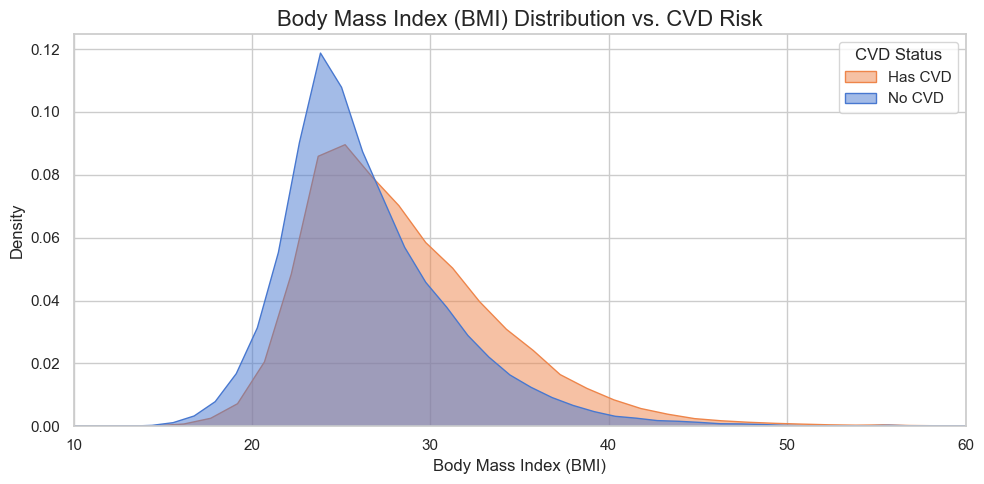

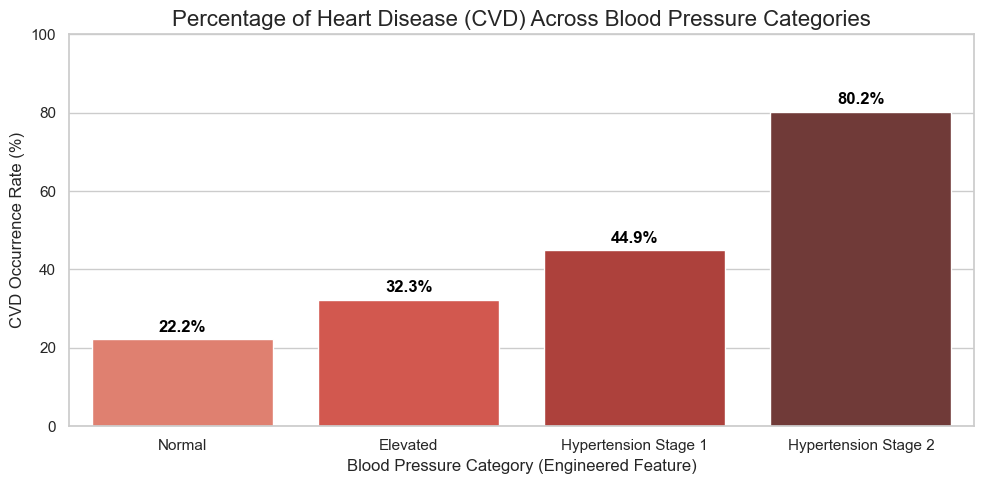

In [3]:
# Set the styling for our publication/video ready charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# --- Plot 1: BMI Distribution by CVD Status ---
plt.figure(figsize=(10, 5))
sns.kdeplot(data=processed_df, x='BMI', hue='CVD', fill=True, common_norm=False, palette='muted', alpha=0.5)
plt.title('Body Mass Index (BMI) Distribution vs. CVD Risk')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Density')
plt.xlim(10, 60) # Limit x-axis to focus on realistic biological ranges
plt.legend(title='CVD Status', labels=['Has CVD', 'No CVD'])
plt.tight_layout()
plt.show()

print("\n") # Line break between charts

# --- Plot 2: Blood Pressure Status vs CVD Rates ---
# Calculate the percentage of CVD cases per blood pressure tier
bp_cvd_rates = processed_df.groupby('BP_Status')['CVD'].mean().reset_index()
bp_cvd_rates['CVD_Percentage'] = bp_cvd_rates['CVD'] * 100

# Sort from lowest risk category to highest risk category for clear storytelling
order = ['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']
bp_cvd_rates['BP_Status'] = pd.Categorical(bp_cvd_rates['BP_Status'], categories=order, ordered=True)
bp_cvd_rates = bp_cvd_rates.sort_values('BP_Status')

plt.figure(figsize=(10, 5))
sns.barplot(data=bp_cvd_rates, x='BP_Status', y='CVD_Percentage', palette='Reds_d')
plt.title('Percentage of Heart Disease (CVD) Across Blood Pressure Categories')
plt.xlabel('Blood Pressure Category (Engineered Feature)')
plt.ylabel('CVD Occurrence Rate (%)')
plt.ylim(0, 100)

# Add value labels on top of the bars for crisp readability
for index, row in enumerate(bp_cvd_rates.itertuples()):
    plt.text(index, row.CVD_Percentage + 2, f"{row.CVD_Percentage:.1f}%", color='black', ha="center", weight='bold')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# 1. Feature Selection and One-Hot Encoding
# We drop 'Age' (since we engineered 'Age_Years') and the target 'CVD'
X = processed_df.drop(columns=['Age', 'CVD'])
y = processed_df['CVD']

# Convert categorical text features (like Gender and BP_Status) into numerical flags
X = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("--- Data Array Shapes ---")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}\n")

# 3. Model Initialization and Training
# scale_pos_weight balances variations; random_state ensures reproducible results
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost Classifier...")
model.fit(X_train, y_train)
print("Model training complete! Evaluating metrics...\n")

# 4. Predictions and Performance Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Output the main classification evaluation metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_proba)
print(f"Area Under the ROC Curve (AUC-ROC): {auc_score:.4f}")

# Display a clean text-based Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(f"True Negatives (Correctly predicted Healthy): {cm[0][0]}")
print(f"False Positives (False Alarms): {cm[0][1]}")
print(f"False Negatives (Missed Sick Patients): {cm[1][0]}")
print(f"True Positives (Correctly predicted CVD): {cm[1][1]}")

ModuleNotFoundError: No module named 'xgboost'

In [5]:
!pip install xgboost


     ------------------------------------ 101.7/101.7 MB 985.9 kB/s eta 0:00:00


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# 1. Feature Selection and One-Hot Encoding
# Drop 'Age' (since we engineered 'Age_Years') and the target variable 'CVD'
X = processed_df.drop(columns=['Age', 'CVD'])
y = processed_df['CVD']

# Convert categorical text features (like Gender and BP_Status) into numerical flags
X = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("--- Data Array Shapes ---")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}\n")

# 3. Model Initialization and Training
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost Classifier...")
model.fit(X_train, y_train)
print("Model training complete! Evaluating metrics...\n")

# 4. Predictions and Performance Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Output the main classification evaluation metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_proba)
print(f"Area Under the ROC Curve (AUC-ROC): {auc_score:.4f}")

# Display a clean text-based Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(f"True Negatives (Correctly predicted Healthy): {cm[0][0]}")
print(f"False Positives (False Alarms): {cm[0][1]}")
print(f"False Negatives (Missed Sick Patients): {cm[1][0]}")
print(f"True Positives (Correctly predicted CVD): {cm[1][1]}")

--- Data Array Shapes ---
Training Features Shape: (54932, 18)
Testing Features Shape: (13733, 18)

Training XGBoost Classifier...
Model training complete! Evaluating metrics...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6940
           1       0.76      0.68      0.72      6793

    accuracy                           0.74     13733
   macro avg       0.74      0.73      0.73     13733
weighted avg       0.74      0.74      0.73     13733

Area Under the ROC Curve (AUC-ROC): 0.8037

--- Confusion Matrix ---
True Negatives (Correctly predicted Healthy): 5487
False Positives (False Alarms): 1453
False Negatives (Missed Sick Patients): 2181
True Positives (Correctly predicted CVD): 4612


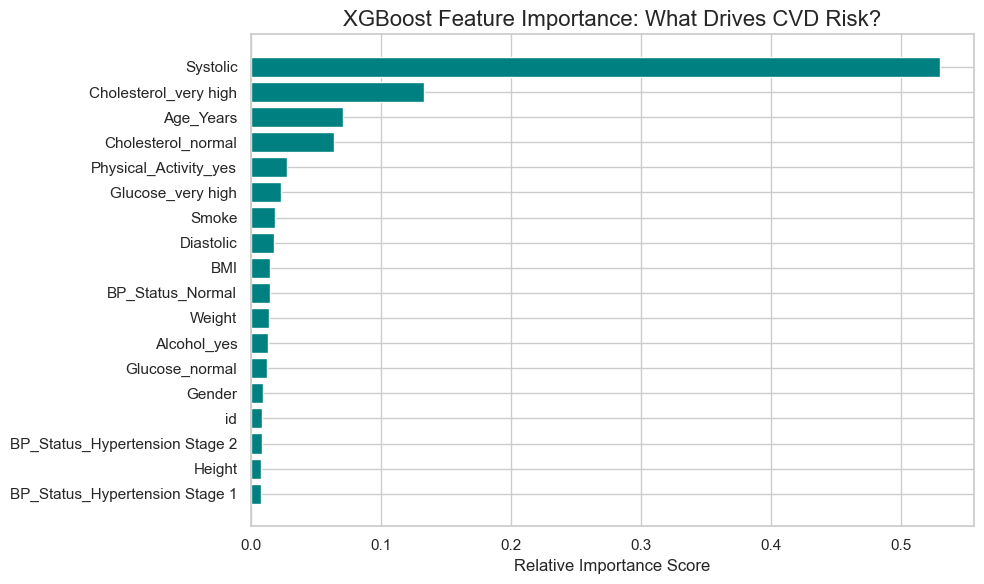

In [7]:
import matplotlib.pyplot as plt

# Get feature importance weights from XGBoost
importance = model.feature_importances_
feature_names = X.columns

# Create a clean DataFrame for sorting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='teal')
plt.title('XGBoost Feature Importance: What Drives CVD Risk?')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()